# Medical VQA — BLIP-2 Open-Ended Captioning

This notebook upgrades the open-ended captioning branch from BLIP to BLIP-2.
BLIP-2 is an instruction-following vision-language model that can answer
question prompts directly — making it better suited for medical VQA than BLIP base.

**Why BLIP-2 over BLIP:**
- BLIP base was designed for simple image captioning, not instruction following
- BLIP-2 connects a frozen image encoder to a large language model (OPT-2.7B)
  via a lightweight Q-Former bridge, enabling it to follow question prompts
- No fine-tuning required — BLIP-2 zero-shot outperforms fine-tuned BLIP base
  on instruction-based tasks

**Model:** Salesforce/blip2-opt-2.7b 

## 1. Install Dependencies

In [ ]:
!pip install -q datasets transformers torch torchvision pillow evaluate rouge_score accelerate

## 2. Imports

In [1]:
import io
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
from datasets import load_dataset
from transformers import Blip2Processor, Blip2ForConditionalGeneration

import evaluate

RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
    print('VRAM:', round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1), 'GB')

c:\Users\Micah\Documents\code\Medical_VQA_Classification\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda
GPU: NVIDIA GeForce RTX 5070 Ti
VRAM: 17.1 GB


## 3. Utility Functions

In [2]:
def open_image_from_dataset_value(image_value):
    """Opens an image from different possible HuggingFace/pandas formats."""
    if isinstance(image_value, Image.Image):
        return image_value
    if isinstance(image_value, dict) and image_value.get('bytes') is not None:
        return Image.open(io.BytesIO(image_value['bytes']))
    if isinstance(image_value, dict) and image_value.get('path') is not None:
        return Image.open(image_value['path'])
    return None


def normalize_text(x):
    if x is None:
        return None
    return str(x).strip().lower()


def infer_question_type(answer):
    ans = normalize_text(answer)
    if ans in {'yes', 'no'}:
        return 'binary'
    return 'open_ended'


print('Utilities ready!')

Utilities ready!


## 4. Load Dataset and Filter ROCO Subset

In [3]:
dataset = load_dataset('robailleo/medical-vision-llm-dataset')

train_df = dataset['train'].to_pandas()
val_df   = dataset['validation'].to_pandas()

train_df['question_type'] = train_df['answer'].apply(infer_question_type)
val_df['question_type']   = val_df['answer'].apply(infer_question_type)

# Filter to open-ended (ROCO) only
val_roco = val_df[val_df['question_type'] == 'open_ended'].reset_index(drop=True)

print('Open-ended val size:', len(val_roco))
print('\nSample question:', val_roco['question'].iloc[0])
print('Sample answer:  ', val_roco['answer'].iloc[0])

Open-ended val size: 769

Sample question: what imaging modality was used?
Sample answer:   x-ray


## 5. Load BLIP-2 Model

BLIP-2 is loaded in float16 to reduce VRAM usage.
This brings it from ~24GB (float32) down to ~12GB (float16) — fits on your 5070 Ti.

In [5]:
MODEL_NAME = 'Salesforce/blip2-opt-2.7b'

print('Loading BLIP-2 processor...')
processor = Blip2Processor.from_pretrained(MODEL_NAME)

print('Loading BLIP-2 model in float16 (reduces VRAM usage)...')
model = Blip2ForConditionalGeneration.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
)
model = model.to(device)
model.eval()

print('BLIP-2 loaded!')
print('Total params:', f"{sum(p.numel() for p in model.parameters()):,}")

if torch.cuda.is_available():
    used_vram = torch.cuda.memory_allocated() / 1e9
    print(f'VRAM used: {used_vram:.1f} GB')

Loading BLIP-2 processor...
Loading BLIP-2 model in float16 (reduces VRAM usage)...


Loading weights: 100%|██████████| 1247/1247 [00:04<00:00, 263.90it/s]


BLIP-2 loaded!
Total params: 3,744,761,856
VRAM used: 7.7 GB


## 6. Evaluation Metrics

In [6]:
bleu  = evaluate.load('bleu')
rouge = evaluate.load('rouge')


def compute_captioning_metrics(predictions, references):
    """
    Computes BLEU and ROUGE scores.
    predictions: list of generated strings
    references:  list of ground truth strings
    """
    # Filter out empty predictions
    filtered = [(p, r) for p, r in zip(predictions, references) if p.strip()]
    if not filtered:
        return {'bleu': 0.0, 'rouge1': 0.0, 'rouge2': 0.0, 'rougeL': 0.0}

    preds, refs = zip(*filtered)
    preds = list(preds)
    refs  = list(refs)

    bleu_refs  = [[r] for r in refs]
    bleu_score = bleu.compute(predictions=preds, references=bleu_refs)
    rouge_score = rouge.compute(predictions=preds, references=refs)

    return {
        'bleu':   round(bleu_score['bleu'], 4),
        'rouge1': round(rouge_score['rouge1'], 4),
        'rouge2': round(rouge_score['rouge2'], 4),
        'rougeL': round(rouge_score['rougeL'], 4),
    }


def print_captioning_metrics(metrics, model_name='Model'):
    print(f"\n{'='*40}")
    print(f'  {model_name}')
    print(f"{'='*40}")
    print(f"  BLEU   : {metrics['bleu']:.4f}")
    print(f"  ROUGE-1: {metrics['rouge1']:.4f}")
    print(f"  ROUGE-2: {metrics['rouge2']:.4f}")
    print(f"  ROUGE-L: {metrics['rougeL']:.4f}")
    print(f"{'='*40}\n")


print('Metrics ready!')

Metrics ready!


## 7. Sanity Check — 5 Samples

Run this first to confirm BLIP-2 is generating coherent medical captions
before running the full evaluation.

In [8]:
def generate_caption(image, question, processor, model, device, max_new_tokens=100):
    """
    Generates a caption for a single image+question pair using BLIP-2.
    BLIP-2 supports instruction following — we pass the question as a prompt.
    """
    img = image.convert('RGB')

    # Format as instruction prompt
    prompt = f"Question: {question} Answer:"

    inputs = processor(
        images=img,
        text=prompt,
        return_tensors='pt'
    ).to(device, torch.float16)

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            num_beams=4,
            repetition_penalty=1.5,
            no_repeat_ngram_size=3,
            length_penalty=1.0,
            early_stopping=True,
        )

    generated = processor.decode(output_ids[0], skip_special_tokens=True)

    if 'Answer:' in generated:
        generated = generated.split('Answer:')[-1].strip()
        
    return generated.strip()


# Sanity check on 5 samples
sample_df = val_roco.sample(5, random_state=RANDOM_STATE).reset_index(drop=True)

print('=== Sanity Check — 5 Samples ===\n')
for i, row in sample_df.iterrows():
    img = open_image_from_dataset_value(row['image'])
    if img is None:
        continue

    generated = generate_caption(img, row['question'], processor, model, device)

    print(f'--- Sample {i+1} ---')
    print(f'Question:  {row["question"]}')
    print(f'Generated: {generated}')
    print(f'Reference: {row["answer"]}')
    print()

=== Sanity Check — 5 Samples ===

--- Sample 1 ---
Question:  where is the mass located?
Generated: on the left side of the brain
Reference: suprasellar

--- Sample 2 ---
Question:  Describe the medical findings in this image.
Generated: The medial epicondyle of the humerus has been displaced anteriorly
Reference: MR arthrography, sagittal oblique T1-weighted image. In a patient with adhesive capsulitis for 15 weeks, the fat triangle (arrowheads) signal is considerably reduced

--- Sample 3 ---
Question:  Describe the medical findings in this image.
Generated: aortic valve stenosis is a narrowing of the aorta
Reference: Perfusing the Left Lung Stent placement in the LPA via catheterization to increase perfusion to the left lung.

--- Sample 4 ---
Question:  Describe the medical findings in this image.
Generated: This image shows a patient with a large mass on the right side of the abdomen
Reference: Axial CT scan showed a huge left sacral expansive lesions with marginal sclerosis(S1-2)

## 8. Full Evaluation on Validation Set

Runs BLIP-2 zero-shot on the full ROCO validation set.
Expected time: ~30-45 minutes on RTX 5070 Ti.

In [9]:
def run_blip2_evaluation(df, processor, model, device, max_new_tokens=100):
    """
    Runs BLIP-2 inference on full dataframe and returns predictions + references.
    """
    model.eval()
    predictions = []
    references  = []

    for idx, row in df.iterrows():
        img = open_image_from_dataset_value(row['image'])
        if img is None:
            continue

        generated = generate_caption(
            img, row['question'], processor, model, device, max_new_tokens
        )

        predictions.append(generated)
        references.append(str(row['answer']))

        if idx % 50 == 0:
            print(f'  [{idx}/{len(df)}] done')
            if idx > 0:
                print(f'  Last generated: {generated[:80]}...')

    return predictions, references


print('Running full BLIP-2 evaluation on validation set...')
print('Expected time: ~30-45 minutes\n')

blip2_preds, blip2_refs = run_blip2_evaluation(val_roco, processor, model, device)

metrics_blip2 = compute_captioning_metrics(blip2_preds, blip2_refs)
print_captioning_metrics(metrics_blip2, model_name='BLIP-2 (OPT-2.7B) Zero-Shot')

Running full BLIP-2 evaluation on validation set...
Expected time: ~30-45 minutes

  [0/769] done
  [50/769] done
  Last generated: on the left side of the liver...
  [100/769] done
  Last generated: The patient has a large mass in the right lower quadrant...
  [150/769] done
  Last generated: The patient presented with a right upper quadrant abdominal pain...
  [200/769] done
  Last generated: The patient has a hypothyroidism...
  [250/769] done
  Last generated: The patient has a spinal cord lesion...
  [300/769] done
  Last generated: the liver...
  [350/769] done
  Last generated: This is an ultrasound image of a patient's abdomen and pelvis...
  [400/769] done
  Last generated: This is an abdominal computed tomography (a ct) scan of the abdomen, showing the...
  [450/769] done
  Last generated: This is a brain scan of a patient who has had a stroke...
  [500/769] done
  Last generated: aortic stenosis...
  [550/769] done
  Last generated: on the left side of the image...
  [600/76

## 9. Full Results Comparison Table

In [10]:
# Hardcoded results from BLIP base experiments
metrics_blip_zeroshot  = {'bleu': 0.0000, 'rouge1': 0.0518, 'rouge2': 0.0034, 'rougeL': 0.0427}
metrics_blip_finetuned = {'bleu': 0.0000, 'rouge1': 0.0953, 'rouge2': 0.0097, 'rougeL': 0.0873}

results = pd.DataFrame([
    {'Model': 'BLIP Base Zero-Shot',              **metrics_blip_zeroshot},
    {'Model': 'BLIP Base Fine-Tuned (Frozen Vision)', **metrics_blip_finetuned},
    {'Model': 'BLIP-2 OPT-2.7B Zero-Shot',        **metrics_blip2},
])

print(results.to_string(index=False))
results.to_csv('blip2_full_results.csv', index=False)
print('\nFull results saved to blip2_full_results.csv')

                               Model   bleu  rouge1  rouge2  rougeL
                 BLIP Base Zero-Shot 0.0000  0.0518  0.0034  0.0427
BLIP Base Fine-Tuned (Frozen Vision) 0.0000  0.0953  0.0097  0.0873
           BLIP-2 OPT-2.7B Zero-Shot 0.0039  0.1409  0.0335  0.1251

Full results saved to blip2_full_results.csv


## 10. Qualitative Sample Predictions

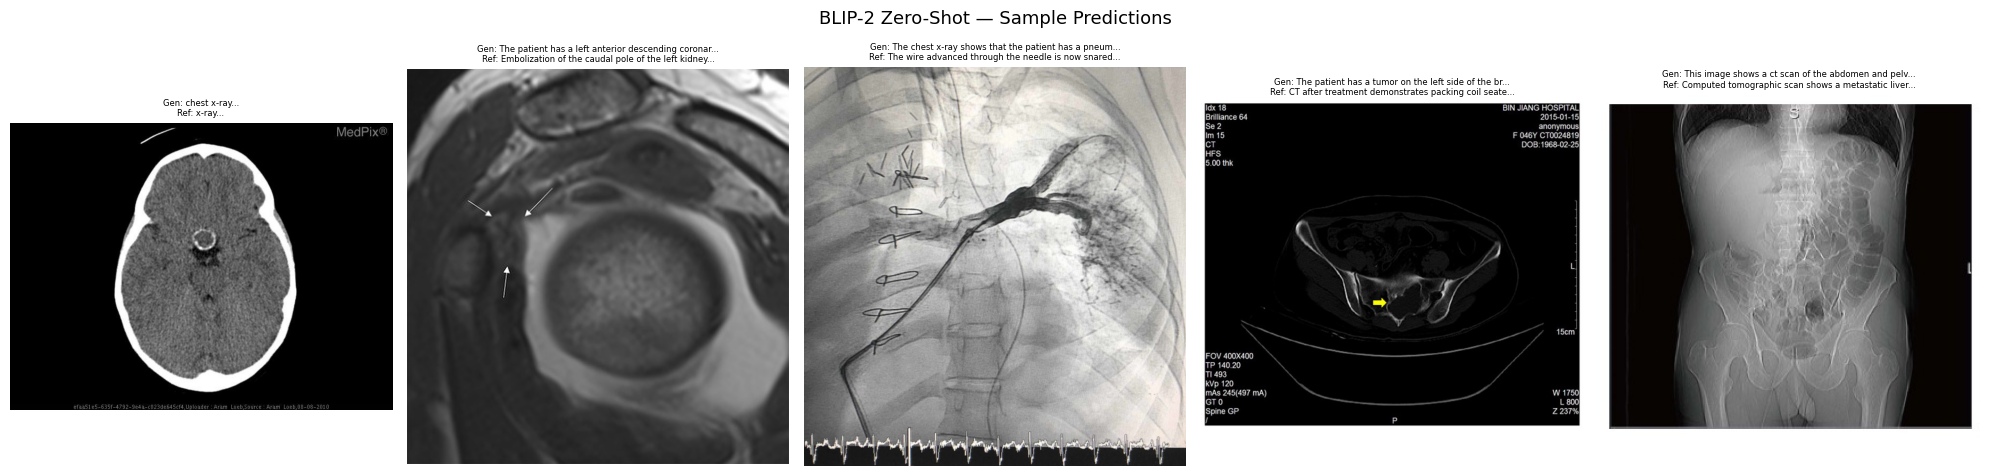

Sample predictions figure saved!


In [11]:
# Show 5 sample predictions with images
sample_df   = val_roco.sample(5, random_state=RANDOM_STATE).reset_index(drop=True)
sample_idxs = sample_df.index.tolist()

sample_preds = [blip2_preds[i] for i in sample_idxs]
sample_refs  = [blip2_refs[i]  for i in sample_idxs]

fig, axes = plt.subplots(1, 5, figsize=(20, 5))
fig.suptitle('BLIP-2 Zero-Shot — Sample Predictions', fontsize=13)

for i, ax in enumerate(axes):
    img = open_image_from_dataset_value(sample_df.iloc[i]['image'])
    ax.imshow(img.convert('RGB'))
    ax.axis('off')
    title = f"Gen: {sample_preds[i][:50]}...\nRef: {sample_refs[i][:50]}..."
    ax.set_title(title, fontsize=6, wrap=True)

plt.tight_layout()
plt.savefig('blip2_sample_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sample predictions figure saved!')

In [12]:
# Print full text comparison
print('\n=== BLIP-2 Sample Predictions vs References ===\n')
for i, (pred, ref) in enumerate(zip(sample_preds, sample_refs)):
    print(f'--- Sample {i+1} ---')
    print(f'Question:  {sample_df.iloc[i]["question"]}')
    print(f'Generated: {pred}')
    print(f'Reference: {ref}')
    print()


=== BLIP-2 Sample Predictions vs References ===

--- Sample 1 ---
Question:  where is the mass located?
Generated: chest x-ray
Reference: x-ray

--- Sample 2 ---
Question:  Describe the medical findings in this image.
Generated: The patient has a left anterior descending coronary artery aneurysm
Reference: Embolization of the caudal pole of the left kidney. Perfusion of blood vessels in the cranial pole of the left kidney is visualized using contrast angiography.

--- Sample 3 ---
Question:  Describe the medical findings in this image.
Generated: The chest x-ray shows that the patient has a pneumothorax, or collapsed lung
Reference: The wire advanced through the needle is now snared by a goose neck snare placed using the left internal jugular vein approach. 190 × 190 mm (137 × 137 DPI)

--- Sample 4 ---
Question:  Describe the medical findings in this image.
Generated: The patient has a tumor on the left side of the brain
Reference: CT after treatment demonstrates packing coil seated 

## 11. Save All Predictions

In [ ]:
final_df = pd.DataFrame({
    'question':            val_roco['question'].tolist(),
    'reference':           blip2_refs,
    'blip_zeroshot':       [None] * len(blip2_refs),  # not rerun, saved separately
    'blip_finetuned':      [None] * len(blip2_refs),  # not rerun, saved separately
    'blip2_zeroshot':      blip2_preds,
})

final_df.to_csv('blip2_all_predictions.csv', index=False)
print('All predictions saved to blip2_all_predictions.csv')